In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import random
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_predict, cross_val_score, KFold, StratifiedKFold, LeaveOneOut, RepeatedStratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from sklearn import metrics

# PCA
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification

# MLPN
from sklearn.neural_network import MLPClassifier

# DEAP
from deap import base, creator, tools, algorithms
from keras import optimizers

# Particle Swarm Optimization - PSO
import pyswarms as ps

# SVM Classifier
from sklearn.svm import SVC

# Quadratic Discriminant Analysis Classifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Ridge Classifier
from sklearn.linear_model import RidgeClassifier

# Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier

# Differential Evolution
from scipy.optimize import differential_evolution

In [2]:
data = pd.read_csv(r"C:\Users\prane\OneDrive\Documents\Amrita Viswa Vidyapeetham\Semseter-5\Foundations of Data Science\Project\processed_cleveland.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1


In [3]:
data.rename(columns={'num': 'presence'}, inplace=True)

<span style="font-size: 22px; color: green; font-weight: bold">Data Preprocessing</span>

<span style="font-size: 16px; color: green; font-weight: bold">Data Inspection</span>

In [4]:
# To get number of rows and columns in the dataset
num_rows, num_columns = data.shape
num_rows, num_columns

(303, 14)

In [5]:
data.replace("?", pd.NA, inplace=True)

In [6]:
# To find the number of missing values in each column
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
presence    0
dtype: int64

<span style="font-size: 16px; color: green; font-weight: bold">Handling missing values</span>

In [7]:
data.dropna(inplace=True)

In [8]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
presence    0
dtype: int64

In [9]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,presence
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3


<span style="font-size: 16px; color: green; font-weight: bold">Mapping values greater than 0 to 1 (indicating presence of heart disease)</span>

In [10]:
data['presence'] = data['presence'].apply(lambda x: 1 if x > 0 else x)

In [11]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,presence
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1


<span style="font-size: 16px; color: green; font-weight: bold">Data Visualization</span>

In [12]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca           object
thal         object
presence      int64
dtype: object

In [13]:
data['thal'] = pd.to_numeric(data['thal'])

In [14]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca           object
thal          int64
presence      int64
dtype: object

In [15]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'presence' ]

In [16]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

In [17]:
# Mapping dictionaries for categorical columns
cp_map = {1: 'typical angina', 2: 'atypical angina', 3: 'non-anginal pain', 4: 'asymptomatic'}
restecg_map = {0: 'normal', 1: 'ST-T wave abnormality', 2: 'probable or definite LVH'}
slope_map = {1: 'upsloping', 2: 'flat', 3: 'downsloping'}
thal_map = {3: 'normal', 6: 'fixed defect', 7: 'reversible defect'}
sex_map = {1: 'male', 0: 'female'}
fbs_map = {1: 'true (>120 mg/dl)', 0: 'false (<=120 mg/dl)'}
exang_map = {1: 'yes', 0: 'no'}
presence_map = {1: 'has heart disease', 0: 'no heart disease'}

In [18]:
# Mapping categorical values to their descriptive names
data['cp'] = data['cp'].map(cp_map)
data['restecg'] = data['restecg'].map(restecg_map)
data['slope'] = data['slope'].map(slope_map)
data['thal'] = data['thal'].map(thal_map)
data['sex'] = data['sex'].map(sex_map)
data['fbs'] = data['fbs'].map(fbs_map)
data['exang'] = data['exang'].map(exang_map)
data['presence'] = data['presence'].map(presence_map)

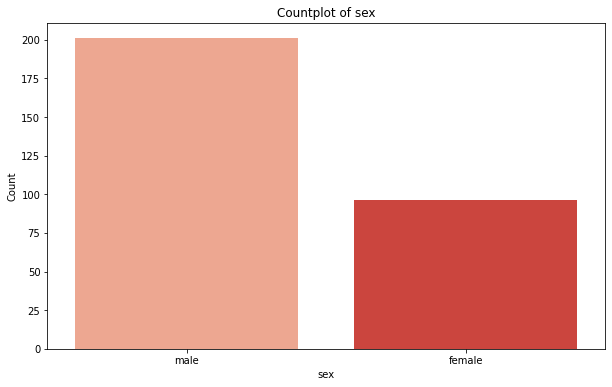

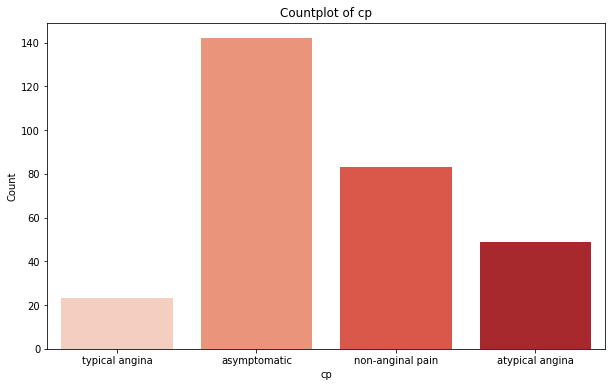

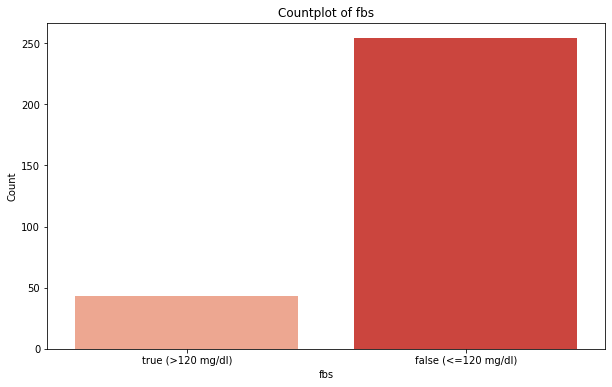

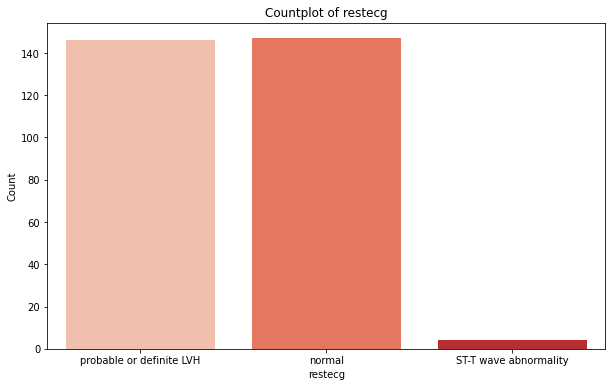

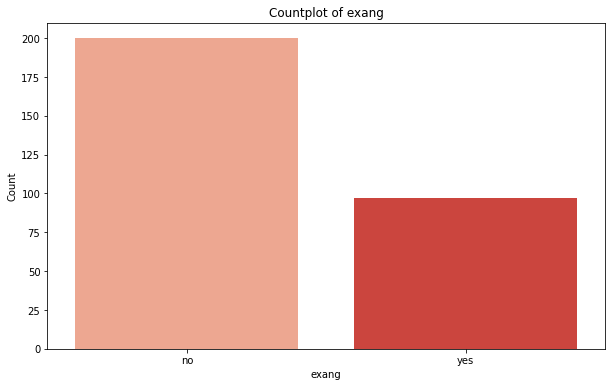

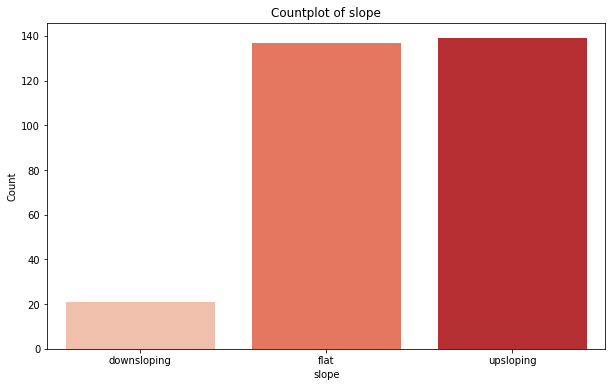

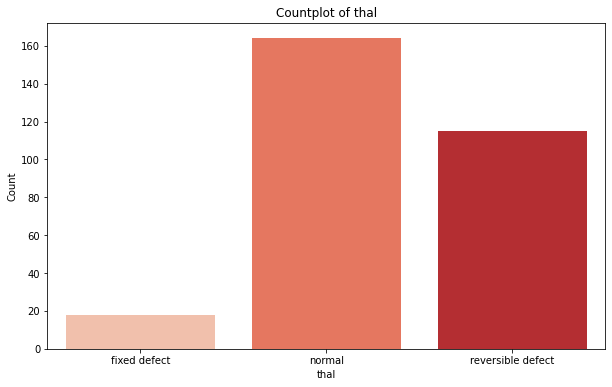

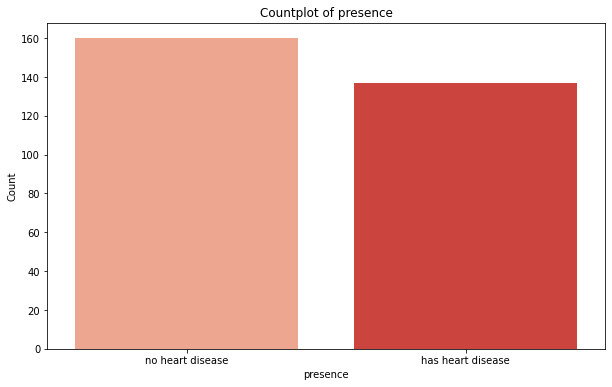

In [19]:
# Count plots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, data=data, palette='Reds')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

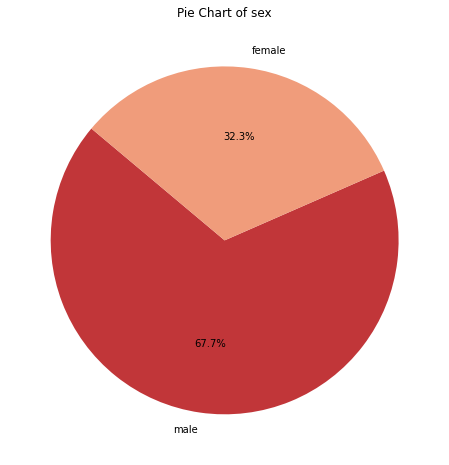

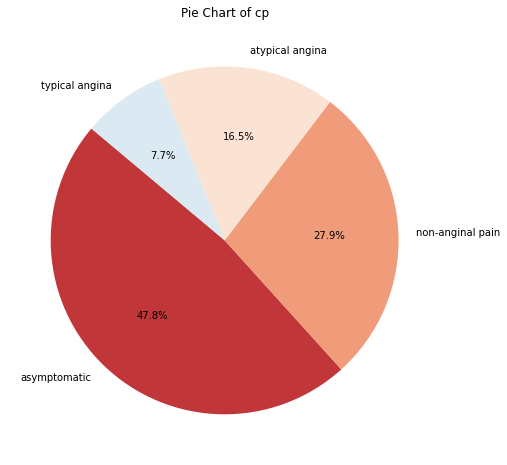

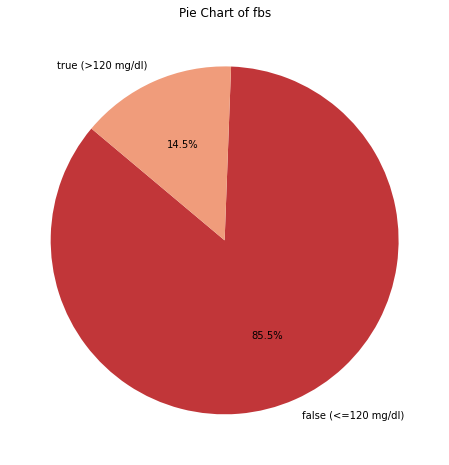

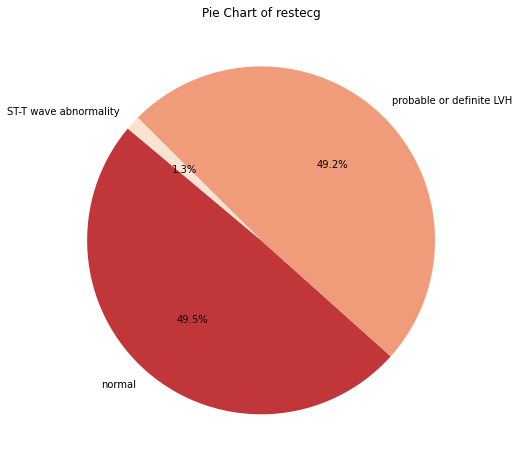

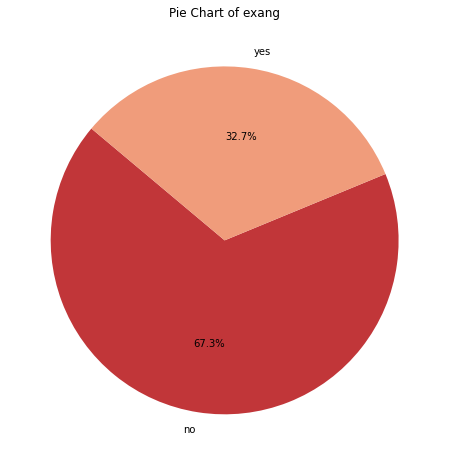

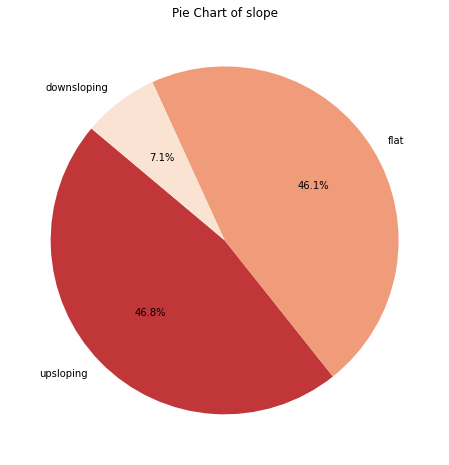

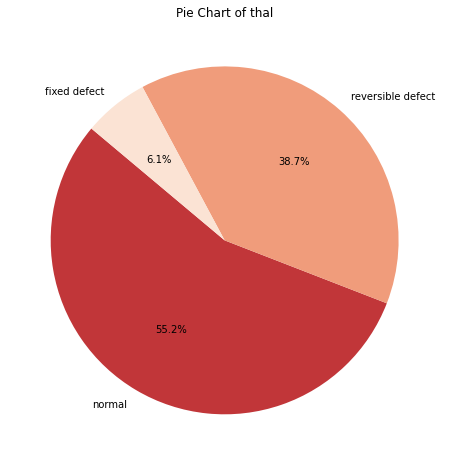

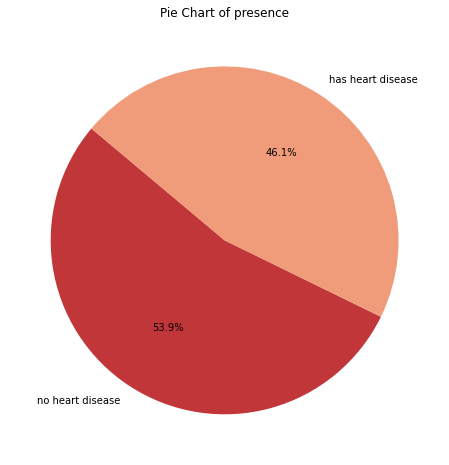

In [20]:
# Pie charts
for col in categorical_cols:
    plt.figure(figsize=(8, 8))
    data[col].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('RdBu'), startangle=140)
    plt.title(f'Pie Chart of {col}')
    plt.ylabel('')
    plt.show()

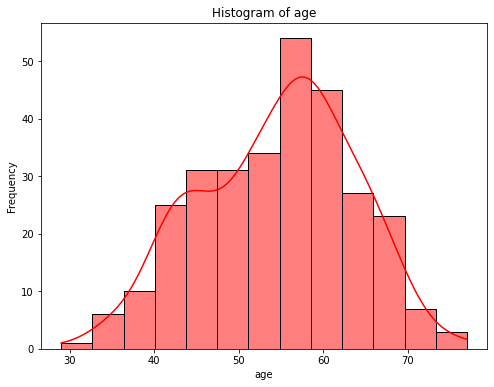

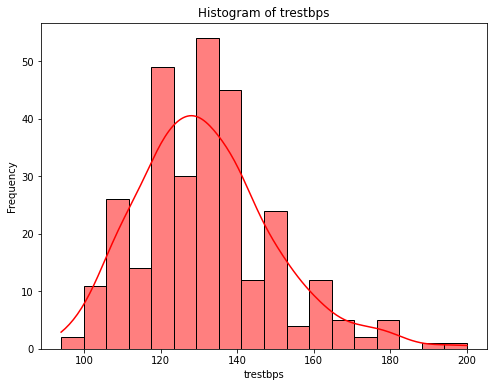

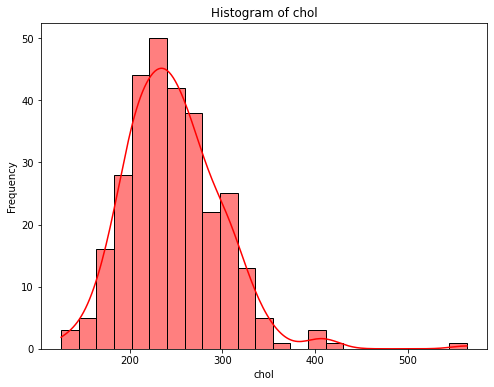

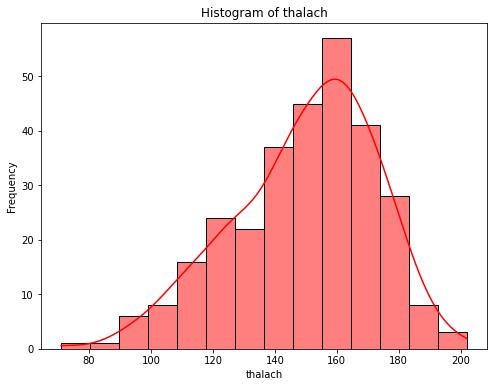

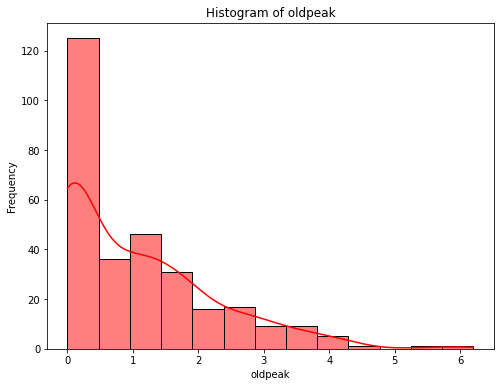

2023-12-04 19:00:49,747 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2023-12-04 19:00:49,751 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


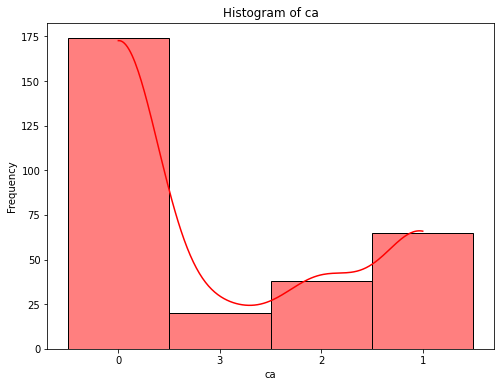

In [21]:
# Histograms for numeric columns

for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[col], kde=True, color='red')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [22]:
data = pd.read_csv(r"C:\Users\prane\OneDrive\Documents\Amrita Viswa Vidyapeetham\Semseter-5\Foundations of Data Science\Project\processed_cleveland.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1


In [23]:
data.rename(columns={'num': 'presence'}, inplace=True)

In [24]:
data.replace("?", pd.NA, inplace=True)
data.dropna(inplace=True)

In [25]:
data['presence'] = data['presence'].apply(lambda x: 1 if x > 0 else x)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,presence
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1


<span style="font-size: 16px; color: green; font-weight: bold">Scaling numeric attributes</span>

In [26]:
# Creating a MinMaxScaler instance
scaler = MinMaxScaler()

In [27]:
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [28]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,presence
0,0.708333,1,1,0.481132,0.244292,1,2,0.603053,0,0.370968,3,0.000000,6,0
1,0.791667,1,4,0.622642,0.365297,0,2,0.282443,1,0.241935,2,1.000000,3,1
2,0.791667,1,4,0.245283,0.235160,0,2,0.442748,1,0.419355,2,0.666667,7,1
3,0.166667,1,3,0.339623,0.283105,0,0,0.885496,0,0.564516,3,0.000000,3,0
4,0.250000,0,2,0.339623,0.178082,0,2,0.770992,0,0.225806,1,0.000000,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,0.583333,0,4,0.433962,0.262557,0,0,0.396947,1,0.032258,2,0.000000,7,1
298,0.333333,1,1,0.150943,0.315068,0,0,0.465649,0,0.193548,2,0.000000,7,1
299,0.812500,1,4,0.471698,0.152968,1,0,0.534351,0,0.548387,2,0.666667,7,1
300,0.583333,1,4,0.339623,0.011416,0,0,0.335878,1,0.193548,2,0.333333,7,1


<span style="font-size: 16px; color: green; font-weight: bold">Data Encoding</span>

In [29]:
data['thal'] = pd.to_numeric(data['thal'])

In [30]:
data.dtypes

age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
presence      int64
dtype: object

Data encoding is not required as every column is of either int or float type

<span style="font-size: 16px; color: green; font-weight: bold">Feature Selection</span>

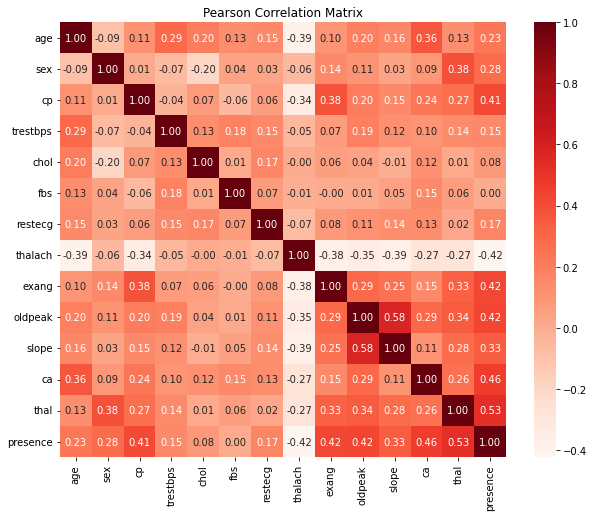

In [31]:
# calculating Pearson correlation matrix
corr_matrix = data.corr()

# plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

Feature Selection based on Correlation Coefficient

In [32]:
target_variable = 'presence'

In [33]:
# Calculating correlations between features and the target variable
correlations = data.drop(target_variable, axis=1).corrwith(data[target_variable])

In [34]:
# Setting a threshold for correlation coefficient
threshold = 0.2

In [35]:
# Select features with correlation coefficients above the threshold
selected_features = correlations[abs(correlations) > threshold].index.tolist()

In [36]:
# Creating a new dataframe
selected_data = data[selected_features + [target_variable]]

selected_data['presence'] = selected_data[target_variable]

selected_data.to_csv('selected_data.csv', index=False)

print("Selected Features:")
print(selected_features)

Selected Features:
['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


C:\Users\prane\AppData\Local\Temp\ipykernel_25960\376842479.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['presence'] = selected_data[target_variable]


In [37]:
data = selected_data
data

,age,sex,cp,thalach,exang,oldpeak,slope,ca,thal,presence
0,0.708333,1,1,0.603053,0,0.370968,3,0.000000,6,0
1,0.791667,1,4,0.282443,1,0.241935,2,1.000000,3,1
2,0.791667,1,4,0.442748,1,0.419355,2,0.666667,7,1
3,0.166667,1,3,0.885496,0,0.564516,3,0.000000,3,0
4,0.250000,0,2,0.770992,0,0.225806,1,0.000000,3,0
...,...,...,...,...,...,...,...,...,...,...
297,0.583333,0,4,0.396947,1,0.032258,2,0.000000,7,1
298,0.333333,1,1,0.465649,0,0.193548,2,0.000000,7,1
299,0.812500,1,4,0.534351,0,0.548387,2,0.666667,7,1
300,0.583333,1,4,0.335878,1,0.193548,2,0.333333,7,1


<span style="font-size: 16px; color: green; font-weight: bold">Data Split</span>

In [38]:
X = data.drop('presence', axis=1)
y = data['presence']

In [39]:
# Splitting the data into training and testing (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (237, 9) (237,)
Testing set shape: (60, 9) (60,)


<span style="font-size: 22px; color: green; font-weight: bold">Model Training</span>

<span style="font-size: 18px; color: green; font-weight: bold">MLPNN</span>

In [41]:
# Initialize the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100, ), activation='tanh', solver='adam', random_state=42)

In [42]:
mlp.get_params()

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': 42,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [43]:
# Fit the MLPClassifier on the training data
mlp.fit(X_train, y_train)

MLPClassifier(activation='tanh', random_state=42)

In [44]:
# Predict on the test set
y_pred = mlp.predict(X_test)

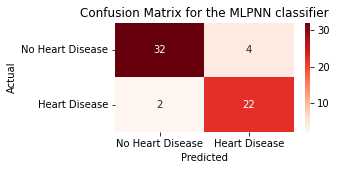

In [45]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the MLPNN classifier')
plt.show()

In [46]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9
Precision: 0.9031674208144796
Recall: 0.9
F1 Score: 0.9005714285714285

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91        36
           1       0.85      0.92      0.88        24

    accuracy                           0.90        60
   macro avg       0.89      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



<span style="font-size: 18px; color: green; font-weight: bold">SVM Classifier</span>

<span style="font-size: 16px; color: green; font-weight: bold">Linear kernel</span>

In [47]:
# Initializing the SVM classifier
svm = SVC(kernel='linear', random_state=42)

In [48]:
svm.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [49]:
# Fit the classifier to the training data
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [50]:
# Predicting on the test data
y_pred = svm.predict(X_test)

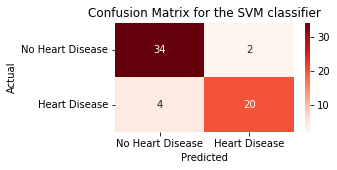

In [51]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the SVM classifier')
plt.show()

In [52]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9
Precision: 0.9004784688995215
Recall: 0.9
F1 Score: 0.8991774383078731

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        36
           1       0.91      0.83      0.87        24

    accuracy                           0.90        60
   macro avg       0.90      0.89      0.89        60
weighted avg       0.90      0.90      0.90        60



<span style="font-size: 18px; color: green; font-weight: bold">SVM with Differential Evolution Algorithm</span>

In [53]:
# Setting a fixed seed for reproducibility
np.random.seed(42)

# Defining the evaluation function to optimize the SVM
def evaluate_SVM(params):
    # Extract hyperparameters
    C = params[0]
    gamma = params[1]

    # Initialize SVM with given hyperparameters
    svm = SVC(C=C, gamma=gamma, kernel='linear')

    # Fit the classifier to the training data
    svm.fit(X_train, y_train)

    # Predicting on the test data
    y_pred = svm.predict(X_test)

    # Calculate evaluation metric (for optimization, e.g., accuracy)
    accuracy = accuracy_score(y_test, y_pred)
    return -accuracy  # Minimize negative accuracy (maximize accuracy)

In [54]:
# Define the bounds for hyperparameters to search within
bounds = [(0.00001, 100), (0.000001, 1)]  # Bounds for C and gamma

In [55]:
# Run Differential Evolution to optimize hyperparameters
result = differential_evolution(evaluate_SVM, bounds, maxiter=50, popsize=10, disp=True)

differential_evolution step 1: f(x)= -0.916667
differential_evolution step 2: f(x)= -0.916667
differential_evolution step 3: f(x)= -0.916667
differential_evolution step 4: f(x)= -0.916667
differential_evolution step 5: f(x)= -0.916667
differential_evolution step 6: f(x)= -0.916667
differential_evolution step 7: f(x)= -0.916667
Polishing solution with 'L-BFGS-B'


In [56]:
# Retrieve the best hyperparameters found
best_params = result.x
best_C = best_params[0]
best_gamma = best_params[1]

In [57]:
# Initialize SVM with the best hyperparameters
best_svm = SVC(C=best_C, gamma=best_gamma, kernel='linear')

In [58]:
best_svm.get_params()

{'C': 9.851747108538753,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 0.5134803937769266,
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [59]:
# Fit the classifier to the training data using the best hyperparameters
best_svm.fit(X_train, y_train)

SVC(C=9.851747108538753, gamma=0.5134803937769266, kernel='linear')

In [60]:
# Predict on the test data using the best model
y_pred_best = best_svm.predict(X_test)

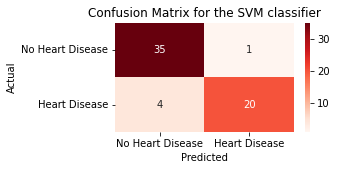

In [61]:
# Print confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the SVM classifier')
plt.show()

In [62]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Model Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))


Best Model Evaluation Metrics:
Accuracy Score: 0.9166666666666666
Precision: 0.9194139194139194
Recall: 0.9166666666666666
F1 Score: 0.9155555555555556

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        36
           1       0.95      0.83      0.89        24

    accuracy                           0.92        60
   macro avg       0.92      0.90      0.91        60
weighted avg       0.92      0.92      0.92        60



<span style="font-size: 18px; color: green; font-weight: bold">SVM with Particle Swarm Optimization Algorithm</span>

In [251]:
np.random.seed(42)
# Define the objective function to optimize SVM hyperparameters using PSO
def objective_function(params):
    C = params[0][0]  # Access the scalar value from the NumPy array
    gamma = params[0][1]  # Access the scalar value from the NumPy array

    # Round the values of C and gamma individually
    C = round(float(C))  # Convert to float before rounding
    gamma = round(float(gamma), 4)

    # Initialize SVM with specified hyperparameters
    svm = SVC(C=C, gamma=gamma, kernel='rbf')
    
    # Fit the SVM model to the training data
    svm.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = svm.predict(X_test)
    
    # Calculate accuracy (minimize negative accuracy)
    return -accuracy_score(y_test, y_pred)

In [252]:
# Set the bounds for C and gamma
bounds = (np.array([1, 0.0001]), np.array([2,0.001]))  # Lower and upper bounds for C and gamma

In [253]:
# Initialize the optimizer with options
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=2, bounds=bounds, options=options)

In [254]:
# Perform optimization to find the best hyperparameters
best_params = optimizer.optimize(objective_function, iters=100)

2023-12-04 19:36:06,632 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|█████████████████████████████████████████████████████████████|100/100, best_cost=-.85
2023-12-04 19:36:07,615 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.85, best pos: [1.74758934e+00 3.99794002e-04]


In [255]:
# Retrieve the best hyperparameters found
best_params = optimizer.optimize(objective_function, iters=100)

2023-12-04 19:36:07,625 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|█████████████████████████████████████████████████████████████|100/100, best_cost=-.85
2023-12-04 19:36:08,500 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.85, best pos: [1.74842783e+00 3.81615461e-04]


In [256]:
# Access the scalar values from the best_params
best_C = max(round(float(best_params[0])), 0.1)  # Convert to float before rounding and ensure it's at least 0.1
best_gamma = max(round(float(best_params[1][0]), 4), 0.0001)  # Accessing the first element if it's an array and ensuring it's at least 0.0001

In [257]:
# Train SVM using the best hyperparameters
best_svm = SVC(C=best_C, gamma=best_gamma, kernel='rbf')
best_svm.fit(X_train, y_train)

SVC(C=0.1, gamma=1.7484)

In [258]:
best_svm.get_params()

{'C': 0.1,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 1.7484,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [259]:
# Predict on the test data using the best model
y_pred_best = best_svm.predict(X_test)

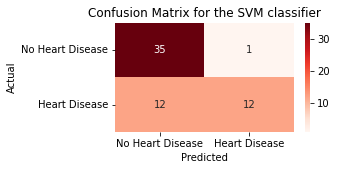

In [260]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the SVM classifier')
plt.show()

In [261]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Model Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))


Best Model Evaluation Metrics:
Accuracy Score: 0.7833333333333333
Precision: 0.816039279869067
Recall: 0.7833333333333333
F1 Score: 0.7654835558450016

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.74      0.97      0.84        36
           1       0.92      0.50      0.65        24

    accuracy                           0.78        60
   macro avg       0.83      0.74      0.75        60
weighted avg       0.82      0.78      0.77        60



<span style="font-size: 18px; color: green; font-weight: bold">QDA Classifier</span>

In [74]:
# Initializing the QDA Classifier
qda = QuadraticDiscriminantAnalysis()

In [75]:
qda.get_params()

{'priors': None, 'reg_param': 0.0, 'store_covariance': False, 'tol': 0.0001}

In [76]:
# Fit the classifier to the training data
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [77]:
# Predicting on the test data
y_pred = qda.predict(X_test)

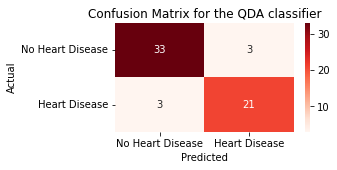

In [78]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the QDA classifier')
plt.show()

In [79]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9
Precision: 0.9
Recall: 0.9
F1 Score: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        36
           1       0.88      0.88      0.88        24

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



<span style="font-size: 18px; color: green; font-weight: bold">QDA Classifier with Differential Evolution Algorithm</span>

In [80]:
# Setting a fixed seed for reproducibility
np.random.seed(42)

# Define the evaluation function for QDA with selected parameters
def evaluate_qda(params):
    # Extract QDA hyperparameters
    reg_param = params[0]
    
    # Initialize QDA with given hyperparameters
    qda = QuadraticDiscriminantAnalysis(reg_param=reg_param)
    
    # Fit the classifier to the training data
    qda.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = qda.predict(X_test)
    
    # Calculate accuracy as the evaluation metric
    accuracy = accuracy_score(y_test, y_pred)
    return -accuracy  # Minimize negative accuracy (maximize accuracy)

In [81]:
# Defining the bounds for hyperparameters to search within
bounds = [(0.0, 1.0)]  # Bounds for regularization parameter

In [82]:
# Run Differential Evolution to optimize QDA hyperparameters
result = differential_evolution(evaluate_qda, bounds, maxiter=50, popsize=10, disp=True)

differential_evolution step 1: f(x)= -0.916667
differential_evolution step 2: f(x)= -0.916667
Polishing solution with 'L-BFGS-B'


In [83]:
# Retrieve the best hyperparameters found
best_params = result.x
best_reg_param = best_params[0]

In [84]:
# Initialize QDA with the best hyperparameters
best_qda = QuadraticDiscriminantAnalysis(reg_param=best_reg_param)

In [85]:
best_qda.get_params()

{'priors': None,
 'reg_param': 0.03745401188473624,
 'store_covariance': False,
 'tol': 0.0001}

In [86]:
# Fit the classifier to the training data using the best hyperparameters
best_qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(reg_param=0.03745401188473624)

In [87]:
# Predict on the test data using the best model
y_pred_best = best_qda.predict(X_test)

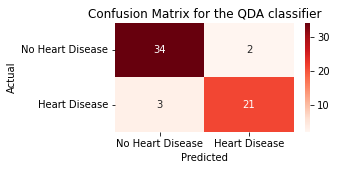

In [88]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the QDA classifier')
plt.show()

In [89]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_best))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Accuracy Score: 0.9166666666666666
Precision: 0.9165687426556991
Recall: 0.9166666666666666
F1 Score: 0.9163509180996794

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        36
           1       0.91      0.88      0.89        24

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60



<span style="font-size: 18px; color: green; font-weight: bold">QDA Classifier with Particle Swarm Optimization Algorithm</span>

In [90]:
np.random.seed(42)

# Defining the objective function to optimize QDA hyperparameters using PSO
def objective_function(params):
    reg_param = params[0][0]  # Access the scalar value from the NumPy array

    # Round the value of reg_param
    reg_param = round(float(reg_param), 4)

    # Initialize QDA with specified hyperparameters
    qda = QuadraticDiscriminantAnalysis(reg_param=reg_param)
    
    # Fit the QDA model to the training data
    qda.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = qda.predict(X_test)
    
    # Calculate accuracy (minimize negative accuracy)
    return -accuracy_score(y_test, y_pred)

In [91]:
# Set the bounds for reg_param
bounds = (np.array([0.00001]), np.array([1]))  # Lower and upper bounds for reg_param

In [92]:
# Initialize the optimizer with options
options = {'c1': 0.8, 'c2': 0.5, 'w': 0.5}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=1, bounds=bounds, options=options)

In [93]:
# Perform optimization to find the best hyperparameters
best_params = optimizer.optimize(objective_function, iters=100)

2023-12-04 19:00:57,140 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.8, 'c2': 0.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████████████████████████████████████████████████████████|100/100, best_cost=-.9
2023-12-04 19:00:57,819 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.9, best pos: [0.12204701]


In [94]:
# Retrieve the best hyperparameters found
best_reg_param = max(round(float(best_params[0])), 0.00001)  # Accessing the scalar value and ensuring it's at least 0.00001

In [95]:
# Train QDA using the best hyperparameters
best_qda = QuadraticDiscriminantAnalysis(reg_param=best_reg_param)
best_qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(reg_param=1e-05)

In [96]:
best_qda.get_params()

{'priors': None, 'reg_param': 1e-05, 'store_covariance': False, 'tol': 0.0001}

In [97]:
# Predict on the test data using the best model
y_pred_best = best_qda.predict(X_test)

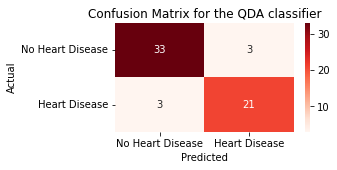

In [98]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the QDA classifier')
plt.show()

In [99]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Model Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))


Best Model Evaluation Metrics:
Accuracy Score: 0.9
Precision: 0.9
Recall: 0.9
F1 Score: 0.9

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        36
           1       0.88      0.88      0.88        24

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



<span style="font-size: 18px; color: green; font-weight: bold">Ridge Classifier</span>

In [100]:
# Initializing the Ridge Classifier
rc = RidgeClassifier()

In [101]:
rc.get_params()

{'alpha': 1.0,
 'class_weight': None,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [102]:
# Fit the classifier to the training data
rc.fit(X_train, y_train)

RidgeClassifier()

In [103]:
# Predicting on the test data
y_pred = rc.predict(X_test)

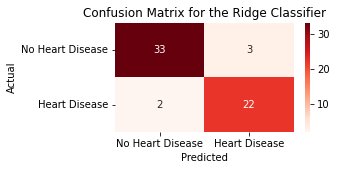

In [104]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Ridge Classifier')
plt.show()

In [105]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9166666666666666
Precision: 0.9177142857142857
Recall: 0.9166666666666666
F1 Score: 0.916930152342627

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       0.88      0.92      0.90        24

    accuracy                           0.92        60
   macro avg       0.91      0.92      0.91        60
weighted avg       0.92      0.92      0.92        60



<span style="font-size: 18px; color: green; font-weight: bold">Ridge Classifier with Differential Evolution Algorithm</span>

In [106]:
# Setting a fixed seed for reproducibility
np.random.seed(42)

# Defining the evaluation function to optimize the Ridge Classifier
def evaluate_ridge(params):
    # Extract hyperparameters
    alpha = params[0]  # Regularization strength

    # Initialize Ridge Classifier with given hyperparameters
    ridge = RidgeClassifier(alpha=alpha)

    # Fit the classifier to the training data
    ridge.fit(X_train, y_train)

    # Predicting on the test data
    y_pred = ridge.predict(X_test)

    # Calculate evaluation metric (for optimization, e.g., accuracy)
    accuracy = accuracy_score(y_test, y_pred)
    return -accuracy  # Minimize negative accuracy (maximize accuracy)

In [107]:
# Define the bounds for hyperparameters to search within
bounds = [(0.001, 10.0)]  # Bounds for alpha

In [108]:
# Run Differential Evolution to optimize hyperparameters
result = differential_evolution(evaluate_ridge, bounds, maxiter=50, popsize=10, disp=True)

differential_evolution step 1: f(x)= -0.916667
Polishing solution with 'L-BFGS-B'


In [109]:
# Retrieve the best hyperparameters found
best_params = result.x
best_alpha = best_params[0]

In [110]:
# Initialize Ridge Classifier with the best hyperparameters
best_ridge = RidgeClassifier(alpha=best_alpha)

In [111]:
best_ridge.get_params()

{'alpha': 6.135519484089232,
 'class_weight': None,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [112]:
# Fit the classifier to the training data using the best hyperparameters
best_ridge.fit(X_train, y_train)

RidgeClassifier(alpha=6.135519484089232)

In [113]:
# Predict on the test data using the best model
y_pred_best = best_ridge.predict(X_test)

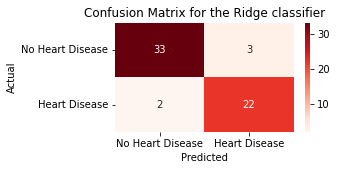

In [114]:
# Print confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Ridge classifier')
plt.show()

In [115]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Ridge Classifier Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Ridge Classifier:")
print(classification_report(y_test, y_pred_best))


Best Ridge Classifier Evaluation Metrics:
Accuracy Score: 0.9166666666666666
Precision: 0.9177142857142857
Recall: 0.9166666666666666
F1 Score: 0.916930152342627

Classification Report for Best Ridge Classifier:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       0.88      0.92      0.90        24

    accuracy                           0.92        60
   macro avg       0.91      0.92      0.91        60
weighted avg       0.92      0.92      0.92        60



<span style="font-size: 18px; color: green; font-weight: bold">Ridge Classifier with Particle Swarm Optimization algorithm</span>

In [262]:
np.random.seed(42)
# Define the objective function to optimize Ridge Classifier hyperparameters using PSO
def objective_function(params):
    alpha = params[0][0]  # Access the scalar value from the NumPy array

    # Round the value of alpha
    alpha = round(float(alpha), 4)

    # Initialize Ridge Classifier with specified hyperparameters
    ridge = RidgeClassifier(alpha=alpha)
    
    # Fit the Ridge Classifier model to the training data
    ridge.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = ridge.predict(X_test)
    
    # Calculate accuracy (minimize negative accuracy)
    return -accuracy_score(y_test, y_pred)

In [263]:
# Set the bounds for alpha
bounds = (np.array([0.0000001]), np.array([1]))  # Lower and upper bounds for alpha

In [264]:
# Initialize the optimizer with options
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=1, bounds=bounds, options=options)

In [265]:
# Perform optimization to find the best hyperparameters
best_params = optimizer.optimize(objective_function, iters=100)

2023-12-04 19:36:52,872 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|████████████████████████████████████████████████████████████|100/100, best_cost=-.917
2023-12-04 19:36:53,595 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.9166666666666666, best pos: [0.47184788]


In [266]:
# Retrieve the best hyperparameters found
best_alpha = max(round(float(best_params[0])), 0.0000001)  # Accessing the scalar value and ensuring it's at least 0.0000001

In [267]:
# Train Ridge Classifier using the best hyperparameters
best_ridge = RidgeClassifier(alpha=best_alpha)
best_ridge.fit(X_train, y_train)

RidgeClassifier(alpha=1e-07)

In [268]:
best_ridge.get_params()

{'alpha': 1e-07,
 'class_weight': None,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [269]:
# Predict on the test data using the best model
y_pred_best = best_ridge.predict(X_test)

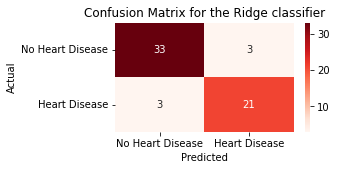

In [270]:
# Print confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Ridge classifier')
plt.show()

In [271]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Model Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))


Best Model Evaluation Metrics:
Accuracy Score: 0.9
Precision: 0.9
Recall: 0.9
F1 Score: 0.9

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        36
           1       0.88      0.88      0.88        24

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



<span style="font-size: 18px; color: green; font-weight: bold">Extra Trees Classifier</span>

In [126]:
# Initializing the ET Classifier
et = ExtraTreesClassifier()

In [127]:
et.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [128]:
# Fit the classifier to the training data
et.fit(X_train, y_train)

ExtraTreesClassifier()

In [129]:
# Predicting on the test data
y_pred = et.predict(X_test)

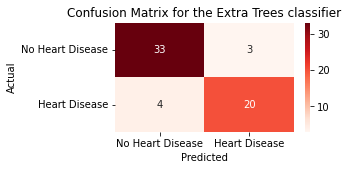

In [130]:
#To print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Extra Trees classifier')
plt.show()

In [131]:
# Evaluation metrics
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.8833333333333333
Precision: 0.8829612220916568
Recall: 0.8833333333333333
F1 Score: 0.8828912853395512

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



<span style="font-size: 18px; color: green; font-weight: bold">Extra Trees Classifier with Differential Evolution Algorithm</span>

In [132]:
# Defining the evaluation function to optimize the Extra Trees Classifier

# Setting a fixed seed for reproducibility
np.random.seed(42)

def evaluate_ET(params):
    # Extract hyperparameters
    n_estimators = int(params[0])
    max_depth = int(params[1]) if params[1] > 0 else None
    min_samples_split = int(params[2])
    min_samples_leaf = int(params[3])

    # Initialize Extra Trees Classifier with given hyperparameters
    et = ExtraTreesClassifier(n_estimators=n_estimators, max_depth=max_depth,
                              min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)

    # Fit the classifier to the training data
    et.fit(X_train, y_train)

    # Predicting on the test data
    y_pred = et.predict(X_test)

    # Calculate evaluation metric (for optimization, e.g., accuracy)
    accuracy = accuracy_score(y_test, y_pred)
    return -accuracy  # Minimize negative accuracy (maximize accuracy)

In [133]:
# Defining the bounds for hyperparameters to search within
bounds = [(50, 500), (1, 50), (2, 20), (1, 10)]  # Bounds for n_estimators, max_depth, min_samples_split, min_samples_leaf

In [134]:
# Run Differential Evolution to optimize hyperparameters
result = differential_evolution(evaluate_ET, bounds, maxiter=50, popsize=10, disp=True)

differential_evolution step 1: f(x)= -0.933333
differential_evolution step 2: f(x)= -0.933333
differential_evolution step 3: f(x)= -0.933333
differential_evolution step 4: f(x)= -0.933333
differential_evolution step 5: f(x)= -0.933333
differential_evolution step 6: f(x)= -0.933333
differential_evolution step 7: f(x)= -0.933333
differential_evolution step 8: f(x)= -0.933333
differential_evolution step 9: f(x)= -0.933333
differential_evolution step 10: f(x)= -0.933333
Polishing solution with 'L-BFGS-B'


In [135]:
# Retrieve the best hyperparameters found
best_params = result.x
best_n_estimators = int(best_params[0])
best_max_depth = int(best_params[1]) if best_params[1] > 0 else None
best_min_samples_split = int(best_params[2])
best_min_samples_leaf = int(best_params[3])

In [136]:
# Initialize Extra Trees Classifier with the best hyperparameters
best_et = ExtraTreesClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth,
                               min_samples_split=best_min_samples_split, min_samples_leaf=best_min_samples_leaf)

In [137]:
best_et.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 27,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 12,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 385,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [138]:
# Fit the classifier to the training data using the best hyperparameters
best_et.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=27, min_samples_leaf=2, min_samples_split=12,
                     n_estimators=385)

In [139]:
# Predict on the test data using the best model
y_pred_best = best_et.predict(X_test)

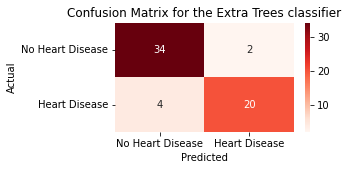

In [140]:
# Print confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for the Extra Trees classifier')
plt.show()

In [141]:
# Calculate evaluation metrics for the best model
accuracy = accuracy_score(y_test, y_pred_best)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred_best, average='weighted')

print("\nBest Model Evaluation Metrics:")
print("Accuracy Score:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", fscore)

print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))



Best Model Evaluation Metrics:
Accuracy Score: 0.9
Precision: 0.9004784688995215
Recall: 0.9
F1 Score: 0.8991774383078731

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        36
           1       0.91      0.83      0.87        24

    accuracy                           0.90        60
   macro avg       0.90      0.89      0.89        60
weighted avg       0.90      0.90      0.90        60



C:\Users\prane\AppData\Local\Temp\ipykernel_25960\3855176843.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8,


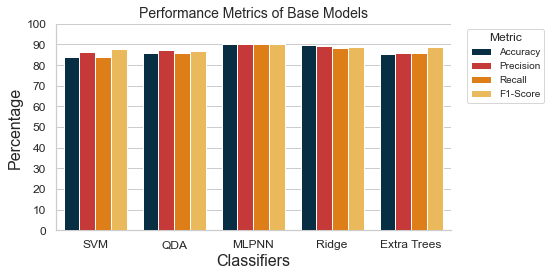

In [326]:
data = {
    'Model': ['SVM', 'QDA', 'MLPNN', 'Ridge', 'Extra Trees'],
    'Accuracy': [84.05, 86.04, 90.0, 89.69, 85.33],
    'Precision': [86.47, 87.27, 90.32, 89.42, 85.71],
    'Recall': [84.05, 86.04, 90.0, 88.17, 86.03],
    'F1-Score': [87.92, 86.83, 90.06, 88.75, 88.94]
}

df = pd.DataFrame(data)

# Coolor palette
colors = ['#003049', '#d62828', '#f77f00', '#fcbf49']

df_melted = pd.melt(df, id_vars=['Model'], var_name='Metric', value_name='Value')

# Plot using Seaborn with adjusted bar width
plt.figure(figsize=(8,4))

# Move grid lines to the background
sns.set(style="whitegrid")
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8, 
                 dodge=True, ci=None, zorder=40, capsize=0.05) 

# Adjust bar width to create more gap between bars
for container in ax.containers:
    container.width = 0.6 

plt.xlabel('Classifiers', fontsize=16) 
plt.ylabel('Percentage', fontsize=16) 
plt.title('Performance Metrics of Base Models', fontsize=14)


plt.yticks(fontsize=12)
plt.ylim(0, 100)  
plt.yticks(range(0, 101, 10)) 

plt.xticks(fontsize=12)

# Move legend outside the plot and to the upper right
plt.legend(title='Metric', loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=10)

# Remove top and right spines
sns.despine()

plt.tight_layout()

plt.show()


C:\Users\prane\AppData\Local\Temp\ipykernel_25960\2342676880.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8,


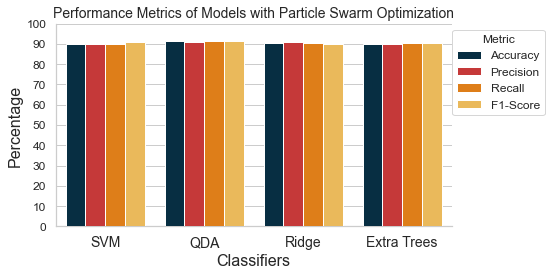

In [325]:
new_data = {
    'Model': ['SVM', 'QDA', 'Ridge', 'Extra Trees'],
    'Accuracy': [90, 91.24, 90.28, 90.22],
    'Precision': [90.05, 90.86, 91.01, 90.19],
    'Recall': [90, 91.24, 90.28, 90.41],
    'F1-Score': [91.18, 91.52, 90.21, 90.37]
}

df = pd.DataFrame(new_data)

# Color palette
colors = ['#003049', '#d62828', '#f77f00', '#fcbf49']

df_melted = pd.melt(df, id_vars=['Model'], var_name='Metric', value_name='Value')

# Plot using Seaborn with adjusted bar width
plt.figure(figsize=(8,4))  

# Move grid lines to the background
sns.set(style="whitegrid")
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8, 
                 dodge=True, ci=None, zorder=40, capsize=0.05)  

# Adjust bar width to create more gap between bars
for container in ax.containers:
    container.width = 0.6  

plt.xlabel('Classifiers', fontsize=16)  
plt.ylabel('Percentage', fontsize=16)  
plt.title('Performance Metrics of Models with Particle Swarm Optimization', fontsize=14)  

plt.yticks(fontsize=12)
plt.ylim(0, 100)  
plt.yticks(range(0, 101, 10)) 

plt.xticks(fontsize=14)

# Move legend outside the plot and to the upper right
plt.legend(title='Metric', loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=12)

# Remove top and right spines
sns.despine()

plt.tight_layout()

plt.show()


C:\Users\prane\AppData\Local\Temp\ipykernel_25960\400496319.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8,


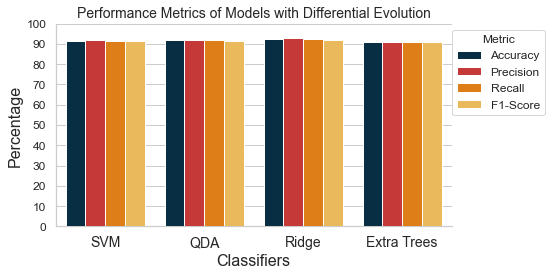

In [324]:
new_data = {
    'Model': ['SVM', 'QDA', 'Ridge', 'Extra Trees'],
    'Accuracy': [91.67, 91.97, 92.61, 91.0],
    'Precision': [91.74, 91.96, 92.77, 91.05],
    'Recall': [91.67, 91.97, 92.61, 91.0],
    'F1-Score': [91.56, 91.64, 92.15, 91.04]
}

df = pd.DataFrame(new_data)

# Color palette
colors = ['#003049', '#d62828', '#f77f00', '#fcbf49']

df_melted = pd.melt(df, id_vars=['Model'], var_name='Metric', value_name='Value')

# Plot using Seaborn with adjusted bar width
plt.figure(figsize=(8,4))  

# Move grid lines to the background
sns.set(style="whitegrid")
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=df_melted, palette=colors, saturation=0.8, 
                 dodge=True, ci=None, zorder=40, capsize=0.05)  

# Adjust bar width to create more gap between bars
for container in ax.containers:
    container.width = 0.6  

plt.xlabel('Classifiers', fontsize=16)  
plt.ylabel('Percentage', fontsize=16)  
plt.title('Performance Metrics of Models with Differential Evolution', fontsize=14)  

plt.yticks(fontsize=12)
plt.ylim(0, 100)  
plt.yticks(range(0, 101, 10)) 

plt.xticks(fontsize=14)

# Move legend outside the plot and to the upper right
plt.legend(title='Metric', loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=12)

# Remove top and right spines
sns.despine()

plt.tight_layout()

plt.show()
